# POD-Based Reduced Order Modeling of Reactive Laminar Boundary Layer Flows

In this study, a high-fidelity numerical solver is used to simulate a 2D laminar boundary layer reactor. (Link:https://github.com/franklingoldsmith/BoundaryLayerModel)

The governing equations are solved for multiple Reynolds numbers, generating a dataset of steady-state temperature fields.

The objective is to develop a Reduced Order Model (ROM) that can:
- Compress the high-dimensional CFD solutions
- Identify dominant flow structures
- Predict new solutions at unseen operating conditions using machine learning

In [1]:
# Import packages
import glob
import os
import pandas as pd
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

## Generation of CFD Snapshot Dataset

The boundary layer code is run locally using Cantera and C++. Inlet flow rate (Reynolds number) is varied and temperature is recorded. 
A total of 31 steady-state simulations were performed using the in-house solver.

Each simulation produces a temperature field:

- Grid size: 10 × 40
- Flattened dimension: 400 DOF per case
- Total snapshots: 31

Each snapshot corresponds to a different Reynolds number, forming a parametric dataset of the system response.


### Construction of Snapshot Matrix

The 2D temperature fields are reshaped into 1D vectors and assembled into a snapshot matrix:

$X = [T_1, T_2, ..., T_{31}]$

where:
- Each column represents one CFD solution
- Each row represents a spatial degree of freedom

This results in a matrix of size:

$ X \in \mathbb{R}^{400 \times 31} $

In [2]:
# Each boundary layer simulation saves a number of solution files at different axial locations. 
# First read those files and retrieve the temperature matrix for each Reynolds number. 
# Since this is a marching algorithm, the grid size is not fixed. 
# For ML model to run, we need a fixed grid (10*40 in this case), so interpolate all matrices and save these outputs.
# The next step is to flatten T vector and create a snapshot matrix
 
# Reynolds number array
Re_array = [50] + list(range(100, 3001, 100))
nRe = len(Re_array)

dir0 = 'C:/brownUniversity/boundary_layer_problem/boundaryLayer_nonDim/ROM_BLruns/pfas/'

# target grid (after inerpolation, we want 10*40 grid)
#     r_new = np.linspace(x_old.min(), x_old.max(), 10) // No need to change the r vector
z_new = np.linspace(0, 12, 40)   # 12 is the length of the reactor

# For snapshot matrix
snapshots = []

for i in range(nRe):

    folder  = dir0 + 'Re_' + str(Re_array[i]) + '/'
    files = glob.glob(os.path.join(folder, "sol_*"))

    # Extract z first (without .csv), then sort
    file_info = []

    for file in files:
        basename = os.path.basename(file)

        # sol_100.csv -> 100
        z = os.path.splitext(basename.split("_")[1])[0]

        file_info.append((float(z), file, z))

    # Sort by numeric z
    file_info.sort(key=lambda x: x[0])

    combined_df = pd.DataFrame()
    first_file = True

    for _, file, z in file_info:

        # Read CSV
        df = pd.read_csv(file)

        # Clean column names
        df.columns = df.columns.str.strip()

        # Find temperature column
        temp_column = None
        for col in df.columns:
            if col.lower() == "temperature":
                temp_column = col
                break

        if temp_column is None:
            print(f"temperature column not found in {file}")
            continue

        # Keep first column only once
        if first_file:
            combined_df[df.columns[0]] = df.iloc[:, 0]
            first_file = False

        # Extract temperature column
        temp_values = df[temp_column].tolist()
       
        # Add temperature column to the file
        combined_df[z] = df[temp_column].values
        
    # replace NaN in dataframe
    combined_df = combined_df.replace(['-nan(ind)', 'nan', 'NaN', ''], np.nan)
    combined_df = combined_df.fillna(0)
    
    # Now the temperature data is saved in combined_df. but we have to interpolate to make sure [r,z] is same
    # extract r and z values

    # r values from first column
    r_old = combined_df['r'].values.astype(float)

    # z values from remaining columns
    z_old = combined_df.columns[1:].astype(float)

    # T values
    T_old = combined_df.iloc[:, 1:].values.astype(float)
        
    # interpolation function
    interp = RegularGridInterpolator((r_old, z_old), T_old, bounds_error=False, fill_value=None)
    
    # create mesh
    Rn, Zn = np.meshgrid(r_old, z_new, indexing="ij") # No need to change r vector

    # interpolate
    points = np.stack([Rn.ravel(), Zn.ravel()], axis=-1)
    T_new = interp(points).reshape(len(r_old), 40)    
        
    # rebuild output table
    output_df = pd.DataFrame(T_new, index=r_old, columns=z_new)
        
    # name the index column
    output_df.index.name = 'r'
    
    # Save output
    output_file = os.path.join(dir0, 'Temperature_Re_' + str(Re_array[i]) + '.csv')   
    output_df.to_csv(output_file, index=True)
    
    # Temperature field to snapshots matrix
    T = output_df.to_numpy(dtype=float)

    # Flatten to snapshot vector
    snapshots.append(T_new.flatten())
    
    # Snapshot matrix
    X = np.array(snapshots).T     # Shape should be (400,num_snapshots): needed for POD

# print("Snapshot matrix shape:", X.shape)

## Proper Orthogonal Decomposition (POD)

POD is used to extract the most energetic modes of the system.

The snapshot matrix is decomposed using Singular Value Decomposition:

\[
X = U \Sigma V^T
\]

Where:
- U: spatial POD modes
- Σ: singular values (energy content)
- V: temporal/parametric coefficients

The goal is to represent the system using only a few dominant modes.

In [3]:
# Compute mean  
X_mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - X_mean

# POD decomposition
U, s, VT = np.linalg.svd(X_centered, full_matrices=False)

## Energy Content of POD Modes

The singular values represent the energy contribution of each mode.

A cumulative energy analysis shows that:

- Mode 1 captures ~96% of total energy
- First 4 modes capture ~100% of the system dynamics

This indicates that the system is highly low-dimensional and suitable for reduced-order modeling.

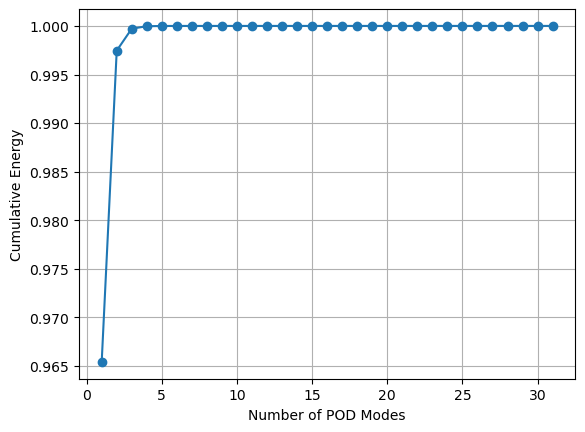

In [4]:
# Compute energy
energy = s**2

# Normalization
energy_ratio = energy / np.sum(energy)

cumulative_energy = np.cumsum(energy_ratio)

plt.plot(
    range(1, len(s)+1),
    cumulative_energy,
    marker='o'
)

plt.xlabel("Number of POD Modes")
plt.ylabel("Cumulative Energy")
plt.grid(True)

plt.show()

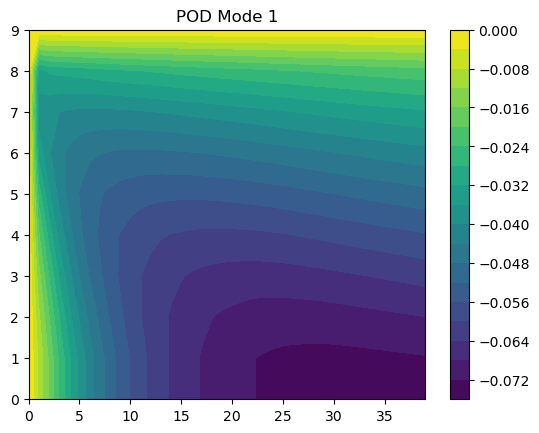

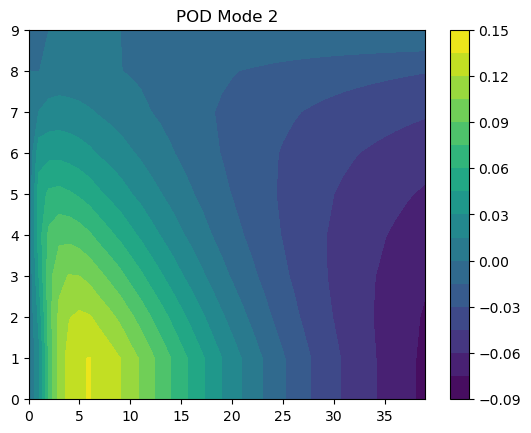

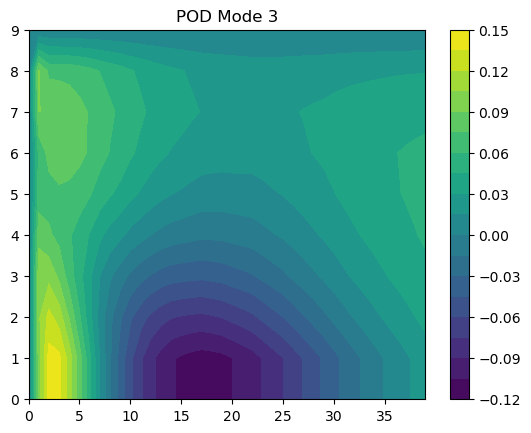

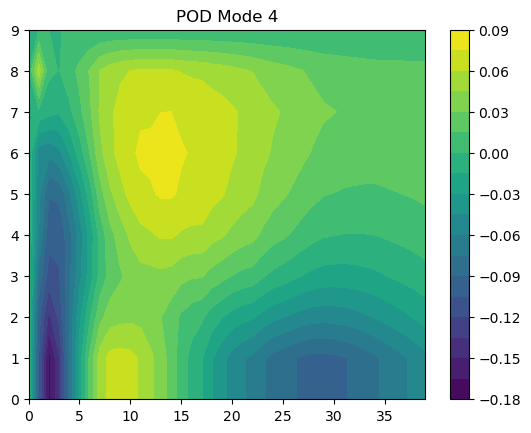

In [5]:
# Plot first few modes
for i in range(4):

    mode = U[:,i].reshape(10, 40)

    plt.figure()

    plt.contourf(mode, levels=20)

    plt.colorbar()

    plt.title(f"POD Mode {i+1}")

    plt.show()

## Field Reconstruction Using POD Modes

Any solution can be approximated as:

$ T(x,y) \approx \bar{T} + \sum_{k=1}^{r} a_k \phi_k(x,y) $

where:
- $\bar{T}$: mean field
- $\phi_k$: POD modes
- $a_k$: modal coefficients
- $r$: number of retained modes

This allows compression of CFD data into a few dominant basis functions.

In [6]:
# Reconstruction
snapshot_id = 5
snapshot = X_centered[:, snapshot_id]

# Mode 1
r = 1

# Extract reduced basis 
Ur = U[:, :r]

# Compute model coeff
coeffs = Ur.T @ snapshot

# Reconstruct
reconstructed = Ur @ coeffs

# Add mean back
reconstructed += X_mean.flatten()

# Reshape to 2D
reconstructed_2D = reconstructed.reshape(10, 40)
original_2D = X[:, snapshot_id].reshape(10, 40)

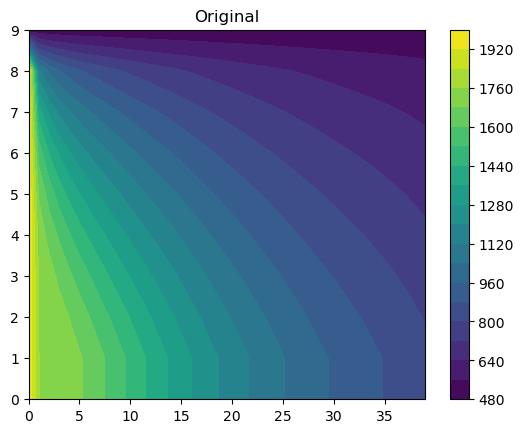

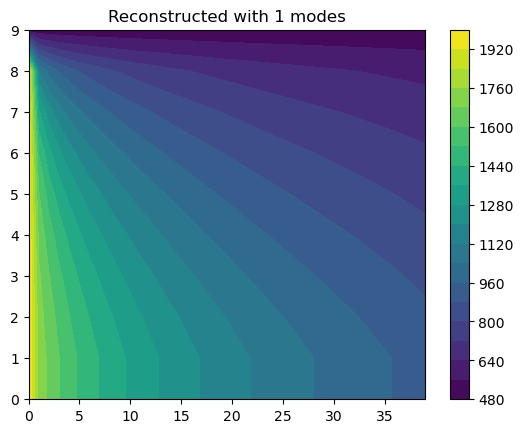

In [7]:
# Plot comparison
plt.figure()
plt.contourf(original_2D, levels=20)
plt.colorbar()
plt.title("Original")

plt.figure()
plt.contourf(reconstructed_2D, levels=20)
plt.colorbar()
plt.title(f"Reconstructed with {r} modes")

plt.show()

In [8]:
# Reconstruction error
error = np.linalg.norm(
    original_2D - reconstructed_2D
) / np.linalg.norm(original_2D)

print("Relative Error =", error)

Relative Error = 0.06249061556193858


## Data-Driven Reduced Order Modeling

To enable prediction at unseen operating conditions, a machine learning model is trained.

The model learns the mapping:

$Re \rightarrow a_k$

where:
- Input: Reynolds number
- Output: POD modal coefficients

Once trained, the model can predict coefficients for new conditions without running CFD simulations.

Predicted coefficients:
[1.20357032 1.17640743 0.46490381 0.87233915]


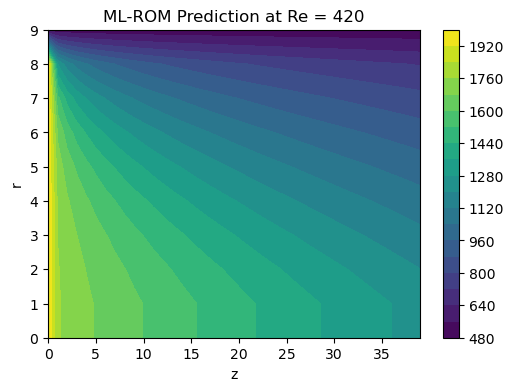

In [17]:
# Train a simple model (The system is low dimensional, so just use linear regression)

# ==================================================
# INPUT DATA
# ==================================================

# Reynolds numbers
# Shape = (31,1)
Re = np.array(Re_array).reshape(-1, 1)

# POD coefficient matrix: coeff
# Keep first 4 modes
A = U.T @ X_centered
A_r = A[:4,:].T

# Shape:
# (31,4)

# ==================================================
# SCALE INPUTS
# ==================================================

x_scaler = StandardScaler()

Re_scaled = x_scaler.fit_transform(Re)

A_scaler = StandardScaler()
A_scaled = A_scaler.fit_transform(A_r)

# ==================================================
# TRAIN SMALL NEURAL NETWORK
# ==================================================

model = MLPRegressor(
    hidden_layer_sizes=(20,20),
    activation='tanh',
    solver='adam',
    max_iter=5000,
    random_state=1
)

model.fit(Re_scaled, A_scaled)

# ==================================================
# PREDICT NEW CONDITION
# ==================================================

Re_new = np.array([[420]])

Re_new_scaled = x_scaler.transform(Re_new)

coeffs_pred = model.predict(Re_new_scaled)

# shape = (1,4)


coeffs_pred = coeffs_pred.flatten()

print("Predicted coefficients:")
print(coeffs_pred)

# ==================================================
# RECONSTRUCT FIELD
# ==================================================

r = 4

Ur = U[:, :r]

reconstructed = Ur @ coeffs_pred

# Add mean field back
reconstructed += X_mean.flatten()

# ==================================================
# RESHAPE TO 2D FIELD
# ==================================================

Nr_common = 10
Nz_common = 40

reconstructed_2D = reconstructed.reshape(
    Nr_common,
    Nz_common
)

# ==================================================
# PLOT RESULT
# ==================================================

plt.figure(figsize=(6,4))

plt.contourf(reconstructed_2D, levels=20)

plt.colorbar()

plt.title(f"ML-ROM Prediction at Re = {Re_new[0,0]}")

plt.xlabel("z")
plt.ylabel("r")

plt.show()

In [23]:
# Training set
train_idx = np.arange(0, 25)
test_idx = np.arange(25, 31)

# Train only on training set
Re_train = Re_scaled[train_idx]
Re_test  = Re_scaled[test_idx]

A_train = A_scaled[train_idx,:]
A_test  = A_scaled[test_idx,:]

# Predict cases
A_pred_scaled = model.predict(Re_test)              # (6,4)
A_pred = A_scaler.inverse_transform(A_pred_scaled)  # (6,4)

# Reconstruct
Ur = U[:, :4]

errors = []

for i in range(len(test_idx)):

    # True field
    T_true = X[:, test_idx[i]]              # (400,)
    
    # ROM reconstruction
    T_rom = Ur @ A_pred[i]                  # (400,)
    T_rom += X_mean.flatten()

    # Error
    err = np.linalg.norm(T_true - T_rom) / np.linalg.norm(T_true)
    errors.append(err)

    print(f"Case {i}, Relative Error = {err:.4f}")

print("Mean test error:", np.mean(errors))

Case 0, Relative Error = 0.0018
Case 1, Relative Error = 0.0003
Case 2, Relative Error = 0.0021
Case 3, Relative Error = 0.0046
Case 4, Relative Error = 0.0075
Case 5, Relative Error = 0.0105
Mean test error: 0.004469491189908255


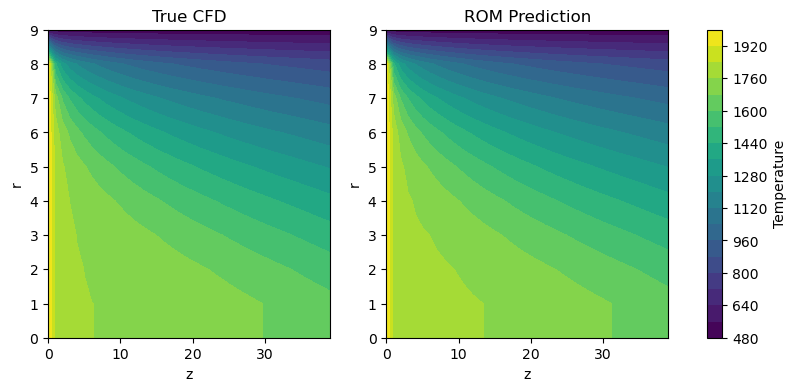

In [33]:
import matplotlib.pyplot as plt

i = 3  # pick a test case

T_true = X[:, test_idx[i]].reshape(10,40)

T_rom = Ur @ A_pred[i]
T_rom += X_mean.flatten()
T_rom = T_rom.reshape(10,40)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
vmin = min(T_true.min(), T_rom.min())
vmax = max(T_true.max(), T_rom.max())

cf1 = axes[0].contourf(T_true, levels=20, vmin=vmin, vmax=vmax)
axes[0].set_title("True CFD")
axes[0].set_xlabel("z")
axes[0].set_ylabel("r")

cf2 = axes[1].contourf(T_rom, levels=20, vmin=vmin, vmax=vmax)
axes[1].set_title("ROM Prediction")
axes[1].set_xlabel("z")
axes[1].set_ylabel("r")

cbar = fig.colorbar(cf1, ax=axes, orientation='vertical')
cbar.set_label("Temperature")

# plt.tight_layout()
plt.show()

## Final Reduced Order Model

The complete ROM framework consists of:

1. High-fidelity CFD solver (data generation)
2. POD-based dimensionality reduction
3. Machine learning model for coefficient prediction
4. Reconstruction of full-field solution

This enables fast approximation of CFD solutions with minimal computational cost while preserving dominant physics.